# Projekt 3: Rendering neuralny modelu oswietlenia Phonga

**Autorzy:** Milosz Andruczyk, Jakub Szewczyk

Celem projektu bylo przygotowanie neuralnego renderera, czyli modelu uczacego sie odwzorowania:

```text
parametry sceny -> obraz wyrenderowany modelem oswietlenia Phonga
```

W projekcie wykorzystano warunkowy model GAN (cGAN). Referencja dla sieci jest generowana klasycznym rendererem OpenGL kula ze shaderem Phonga. Nastepnie generator uczy sie tworzyc obraz kuli na podstawie parametrow sceny, a jakosc wynikow jest porownywana z referencja przy pomocy metryk FLIP, LPIPS, SSIM oraz odleglosci Hausdorffa liczonej na krawedziach z detektora Canny'ego.

## 1. Opis zadania

Zadanie polegalo na zrealizowaniu modelu oswietlenia Phonga przy uzyciu sieci neuronowej. Siec jest spieta z rendererem w tym sensie, ze renderer generuje zbior uczacy: obrazy referencyjne oraz odpowiadajace im parametry sceny.

Przyjete ograniczenia sceny:

- na scenie znajduje sie jeden obiekt: siatka kuli,
- wystepuje jedno punktowe zrodlo swiatla,
- kamera ma stale polozenie,
- obiekt nie jest skalowany ani obracany,
- zmienne sa: polozenie kuli, kolor rozproszenia, wspolczynnik polysku oraz polozenie swiatla,
- obrazki maja rozdzielczosc `128 x 128`,
- wygenerowany zbior danych zawiera `3000` obrazow,
- zbior testowy stanowi `20%`, czyli `600` obrazow.

## 2. Model oswietlenia Phonga

Model Phonga sklada sie z trzech skladowych:

1. **Ambient** - skladowa otoczenia, przybliza swiatlo posrednie.
2. **Diffuse** - skladowa rozproszenia, odpowiada za matowe oswietlenie powierzchni.
3. **Specular** - skladowa odbicia, odpowiada za rozblyski.

W shaderze fragmentow wynikowy kolor jest liczony jako:

```text
I = ambient + diffuse + specular
```

Dla projektu wykorzystano nastepujace stale:

- material ambient: `[0.3, 0.3, 0.3]`, czyli odpowiednik koloru okolo `[76, 76, 76]`,
- material specular: `[1.0, 1.0, 1.0]`, czyli `[255, 255, 255]`,
- light ambient: `[0.1, 0.1, 0.1]`, czyli okolo `[25, 25, 25]`,
- light diffuse: `[1.0, 1.0, 1.0]`,
- light specular: `[1.0, 1.0, 1.0]`.

Kod shadera znajduje sie w `../resources/shaders/phong/phong.frag`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image as IPImage

# Notebook znajduje sie w 3/src. Ten fragment jest odporny rowniez na uruchomienie z katalogu repozytorium.
SRC_DIR = Path.cwd()
if not (SRC_DIR / "utils").exists():
    SRC_DIR = Path("3/src").resolve()

PROJECT_DIR = SRC_DIR.parent
REPO_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / "output_dataset"
DATASET_CSV = DATASET_DIR / "dataset.csv"
SAMPLES_DIR = SRC_DIR / "samples"
RESULTS_CSV = REPO_DIR / "output" / "generator_L1_ResidualLoss_50_0.0002_100" / "wyniki" / "evaluation.csv"

print("SRC_DIR:", SRC_DIR)
print("DATASET_CSV:", DATASET_CSV)
print("RESULTS_CSV:", RESULTS_CSV)

SRC_DIR: /home/milosz16/Uczelnia/SIGK/SIGK-projects/proj3/SIGK-projects/3/src
DATASET_CSV: /home/milosz16/Uczelnia/SIGK/SIGK-projects/proj3/SIGK-projects/3/output_dataset/dataset.csv
RESULTS_CSV: /home/milosz16/Uczelnia/SIGK/SIGK-projects/proj3/SIGK-projects/output/generator_L1_ResidualLoss_50_0.0002_100/wyniki/evaluation.csv


## 3. Generacja zbioru danych

Zbior danych generowany jest przez `main.py`, `base_window.py` oraz `phong_window.py`.

Najwazniejszy przebieg:

1. `main.py` uruchamia konfiguracje okna `PhongWindow`.
2. `BaseWindow` tworzy kontekst OpenGL, laduje model kuli i shadery.
3. `PhongWindow` dla kazdej klatki losuje parametry sceny.
4. Parametry sa przekazywane do shadera jako uniformy.
5. Scena jest renderowana klasycznym modelem Phonga.
6. Obraz jest zapisywany jako `image_XXXX.png`.
7. Parametry sceny sa dopisywane do `dataset.csv`.

Losowane parametry:

| Parametr | Zakres | Znaczenie |
|---|---:|---|
| `model_tx`, `model_ty`, `model_tz` | `[-20, 20]` | polozenie kuli |
| `diffuse_r`, `diffuse_g`, `diffuse_b` | `[0, 255]` | kolor rozproszenia materialu |
| `shininess` | `[3, 20]` | wspolczynnik polysku |
| `light_px`, `light_py`, `light_pz` | `[-20, 20]` | polozenie punktowego swiatla |

W kodzie uwzgledniono tez zabezpieczenie przed sytuacja, w ktorej kula znajdzie sie zbyt blisko kamery. To jest jedna z sytuacji wynikajacych z szerokiego zakresu losowania polozenia: obiekt moglby znalezc sie bardzo blisko kamery lub w niekorzystnym miejscu wzgledem widoku.

In [2]:
df = pd.read_csv(DATASET_CSV)
print("Liczba probek w CSV:", len(df))
print("Liczba obrazow PNG:", len(list(DATASET_DIR.glob("image_*.png"))))
display(df.head())

Liczba probek w CSV: 3000
Liczba obrazow PNG: 3000


,image_file,model_tx,model_ty,model_tz,diffuse_r,diffuse_g,diffuse_b,shininess,light_px,light_py,light_pz
0,image_0000.png,-19.563202,11.974741,-9.559599,87.846577,167.204101,30.728356,6.002461,-19.463705,15.603688,-3.143713
1,image_0001.png,10.074711,11.686922,-7.515606,161.063106,249.625327,182.339834,10.291376,3.131534,19.880312,-1.247162
2,image_0002.png,10.654911,-7.840865,-12.951991,119.495753,108.784784,10.682956,18.971295,5.682348,-8.884783,17.195826
3,image_0003.png,-15.391650,-7.947429,-4.032748,198.516130,62.046137,68.466678,8.767850,-13.769802,4.449710,9.494384
4,image_0004.png,-0.049582,10.031622,-13.644289,166.580096,23.311605,18.685946,12.942058,7.049250,-18.086437,13.869768


## 4. Reprezentacja danych dla sieci

Kazda probka sklada sie z:

```text
obraz referencyjny 128 x 128 RGB
+
wektor 10 parametrow sceny
```

W `utils/dataset.py` obrazy sa normalizowane do zakresu `[-1, 1]`, poniewaz generator konczy sie aktywacja `Tanh()`, ktora generuje wartosci w tym samym zakresie.

Parametry sceny sa rowniez normalizowane:

- polozenie kuli: dzielone przez `20`,
- kolor diffuse: dzielony przez `255`,
- shininess: dzielony przez `20`,
- polozenie swiatla: dzielone przez `20`.

Dzieki temu siec dostaje wartosci o podobnej skali, co stabilizuje trening.

## 5. Proces treningu

Proces treningu znajduje sie w `services.py`.

Dane sa dzielone na:

- `80%` zbior treningowy,
- `20%` zbior testowy.

Dla 3000 obrazow oznacza to:

```text
2400 obrazow treningowych
600 obrazow testowych
```

W kazdej iteracji wykonywane sa dwa kroki:

### Krok 1: trening generatora

1. Generator tworzy obraz `fake_imgs = generator(conditions)`.
2. Dyskryminator ocenia ten obraz.
3. Generator dostaje kare, jesli dyskryminator rozpozna obraz jako falszywy.
4. Generator dostaje tez kare pikselowa za roznice wzgledem referencji.

### Krok 2: trening dyskryminatora

1. Dyskryminator dostaje obraz prawdziwy i powinien zwrocic `1`.
2. Dyskryminator dostaje obraz wygenerowany i powinien zwrocic `0`.
3. Generator jest w tym kroku odciety przez `fake_imgs.detach()`, aby aktualizowac tylko wagi dyskryminatora.

Parametry treningu:

| Parametr | Wartosc |
|---|---:|
| liczba epok | `50` |
| batch size | `128` |
| learning rate | `0.0002` |
| beta1, beta2 dla Adam | `0.5`, `0.999` |
| lambda dla pixel loss | `100` |

## 6. Wyniki wizualne

Ponizej pokazano przykladowe porownania zapisywane podczas treningu. W siatkach pierwsza czesc obrazow to referencje, a druga czesc to obrazy wygenerowane przez generator.

epoch_0_L1_ResidualLoss.png


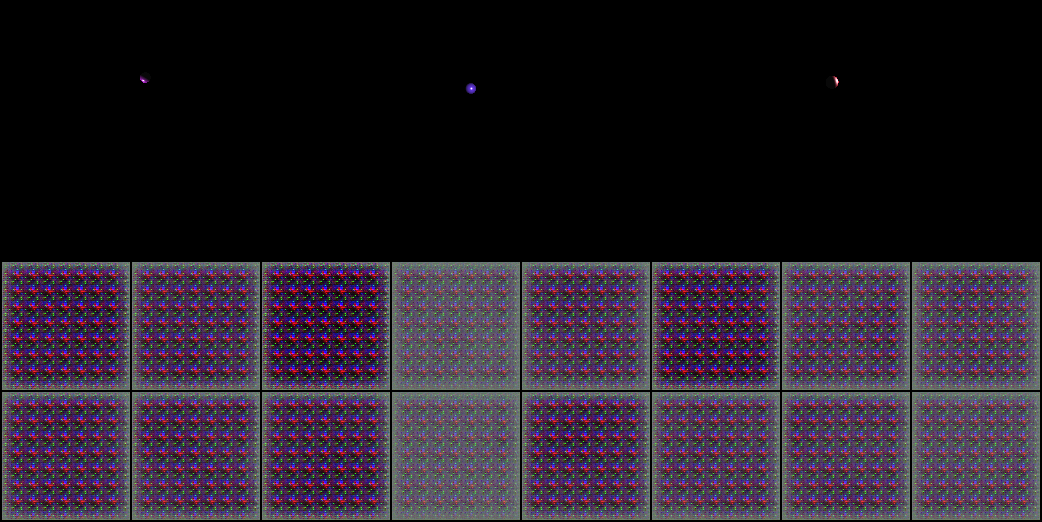

epoch_25_L1_ResidualLoss.png


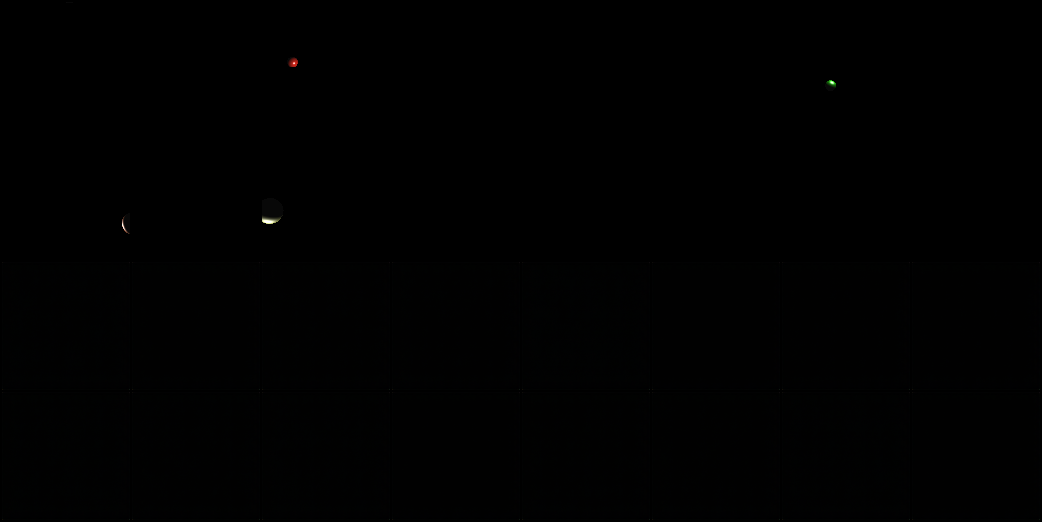

epoch_49_L1_ResidualLoss.png


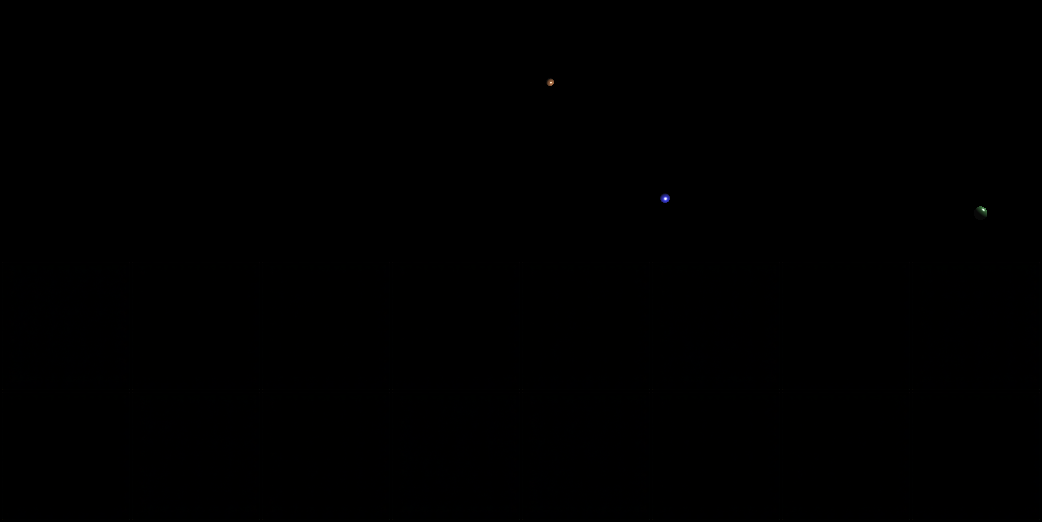

In [7]:
for name in ["epoch_0_L1_ResidualLoss.png", "epoch_25_L1_ResidualLoss.png", "epoch_49_L1_ResidualLoss.png"]:
    path = SAMPLES_DIR / name
    if path.exists():
        print(name)
        display(IPImage(filename=str(path)))
    else:
        print("Brak pliku:", path)

## 7. Metryki ewaluacyjne

Ewaluacja zostala wykonana na zbiorze testowym liczacym `600` obrazow.

Zastosowane metryki:

- **FLIP** - metryka percepcyjna zaprojektowana do oceny roznic miedzy renderami.
- **LPIPS** - metryka percepcyjna oparta na cechach sieci neuronowej.
- **SSIM** - porownuje podobienstwo strukturalne obrazow.
- **Hausdorff** - liczony na punktach krawedzi wyznaczonych detektorem Canny'ego.

In [6]:
results = pd.read_csv(RESULTS_CSV)


report = pd.DataFrame({
    "Metoda": ["neural renderer"],
    "FLIP ": [results["FLIP"].iloc[0] if "FLIP" in results.columns else None],
    "LPIPS ": [results["LPIPS"].iloc[0]],
    "SSIM ": [results["SSIM"].iloc[0]],
    "Hausdorff  ": [results["Hausdorff Distance"].iloc[0]],
})

display(report)

,Metoda,FLIP,LPIPS,SSIM,Hausdorff
0,neural renderer,0.004649,0.036479,0.996586,0.0


## 8. Interpretacja wynikow

Wyniki liczbowe sa bardzo dobre, ale nie oznaczaja, ze generator poprawnie nauczyl sie renderowac sfere z oswietleniem Phonga. Analiza wizualna sampli pokazuje, ze siec w duzej mierze nauczyla sie generowac czarne tlo, natomiast obiekt i jego oswietlenie czesto nie sa odtwarzane poprawnie.

Glowna przyczyna jest niezbalansowana zawartosc obrazow: kula zajmuje bardzo mala liczbe pikseli, a wiekszosc obrazu stanowi czarne tlo. Jezeli generator wygeneruje prawie czarny obraz, to nadal bardzo duza czesc pikseli zgadza sie z referencja. W efekcie metryki globalne moga wygladac dobrze, mimo ze najwazniejszy element sceny, czyli oswietlona kula, nie zostal poprawnie wygenerowany.

Wysokie `SSIM` oraz niskie `LPIPS` i `FLIP` nalezy wiec interpretowac ostroznie. W tym przypadku metryki w duzej mierze premiuja zgodnosc tla, a niekoniecznie jakosc odtworzenia modelu Phonga na obiekcie.

Szczegolnie mylacy jest wynik `Hausdorff = 0.0`. W implementacji, gdy Canny nie wykryje krawedzi w jednym z obrazow, funkcja zwraca `0.0`. Przy prawie czarnych obrazach wygenerowanych przez siec moze to oznaczac nie idealna zgodnosc, lecz brak krawedzi do porownania. Taki wynik nie powinien byc traktowany jako dowod poprawnego wygenerowania konturu sfery.


## 9. Czy wszystkie metryki dobrze oddaja jakosc obrazow?

Nie. W tym eksperymencie metryki nie oddaja w pelni rzeczywistej jakosci generowanych obrazow.

**FLIP**, **LPIPS** i **SSIM** sa przydatne, ale liczone na calym obrazie sa zdominowane przez czarne tlo. Poniewaz tlo zajmuje wiekszosc pikseli, generator moze uzyskac dobre wyniki nawet wtedy, gdy nie generuje poprawnej kuli.

**SSIM** szczegolnie mocno premiuje zgodnosc struktury globalnej. Jezeli wiekszosc obrazu jest czarna zarowno w referencji, jak i predykcji, wynik moze byc bardzo wysoki.

**LPIPS** i **FLIP** sa bardziej percepcyjne, ale rowniez moga byc zanizone, gdy blad dotyczy malego fragmentu obrazu.

**Hausdorff na krawedziach** okazal sie najmniej wiarygodny w obecnej implementacji. Wynik `0.0` moze pojawic sie nie dlatego, ze krawedzie sa idealnie zgodne, ale dlatego, ze w obrazie wygenerowanym nie wykryto krawedzi i funkcja zwrocila wartosc zerowa.

Wniosek: w tym projekcie metryki liczbowe sa zbyt optymistyczne. Do rzetelnej oceny nalezaloby dodatkowo analizowac tylko obszar wokol obiektu, zmienic sposob liczenia Hausdorffa przy braku krawedzi oraz zawsze dolaczac ocene wizualna.


## 10. Podsumowanie

W projekcie przygotowano kompletny pipeline neuralnego renderingu:

1. klasyczny renderer Phonga generuje syntetyczny dataset,
2. zapisuje obrazy oraz parametry sceny,
3. warunkowy GAN uczy sie generowac obraz na podstawie parametrow,
4. jakosc wynikow jest oceniana na 600 obrazach testowych,
5. wyniki sa porownywane przy pomocy FLIP, LPIPS, SSIM i Hausdorffa.

Najwazniejszy wniosek z eksperymentu jest jednak krytyczny: nie udalo sie poprawnie nauczyc generatora stabilnego tworzenia sfer z oswietleniem Phonga. Model nauczyl sie przede wszystkim dominujacego czarnego tla, poniewaz obiekt zajmuje niewielka czesc obrazu. To tlumaczy bardzo dobre wartosci metryk mimo slabszych wynikow wizualnych.

Projekt pokazuje wiec nie tylko sama idee neural renderingu, ale tez ograniczenie zastosowanego podejscia: przy malym obiekcie i duzej przewadze tla klasyczne globalne straty oraz globalne metryki moga prowadzic do mylacej oceny jakosci modelu.
